# Task B1:
Load the downloaded grayscale image, then:
- Apply the three edge detection methods: Laplacian, Sobel, Canny.
- Display original image and highlighted images to see the difference.

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math

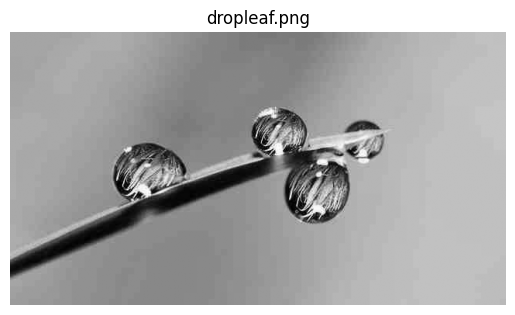

In [3]:
image = cv2.imread("dropleaf.png",0)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("dropleaf.png")
plt.show()

#### Laplacian edge detection

In [4]:
# log = laplacian of gaussian
log_kernel=np.array([
    [0, 0, -1, 0, 0],
    [0, -1, -2, -1, 0],
    [-1, -2, 16, -2, -1],
    [0, -1, -2, -1, 0],
    [0, 0, -1, 0, 0]
])

def log_filter(image):
    output = np.zeros((image.shape[0],image.shape[1]))
    for i in range(2, image.shape[0] - 2):
        for j in range(2, image.shape[1] - 2):
            window=image[i-2:i+3, j-2:j+3]
            output[i, j]=(window*log_kernel).sum()
    return output

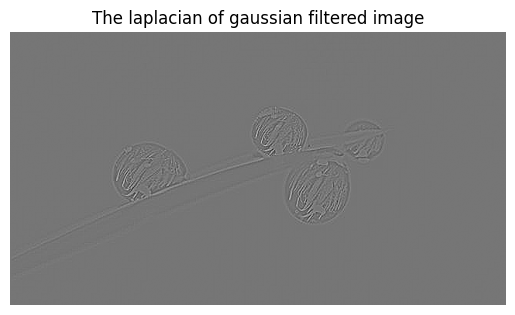

In [5]:
log_image = log_filter(image)

plt.imshow(log_image, cmap="gray")
plt.axis("off")
plt.title("The laplacian of gaussian filtered image")
plt.show()

#### Sobel edge detection

In [6]:
sobel_h_kernel=np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])
sobel_v_kernel=np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

def sobel_v_filter(image):
    output = np.zeros((image.shape[0],image.shape[1]))
    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):
            window=image[i-1:i+2, j-1:j+2]
            output[i, j]=(window*sobel_v_kernel).sum()
    return output
def sobel_h_filter(image):
    output = np.zeros((image.shape[0],image.shape[1]))
    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):
            window=image[i-1:i+2, j-1:j+2]
            output[i, j]=(window*sobel_h_kernel).sum()
    return output

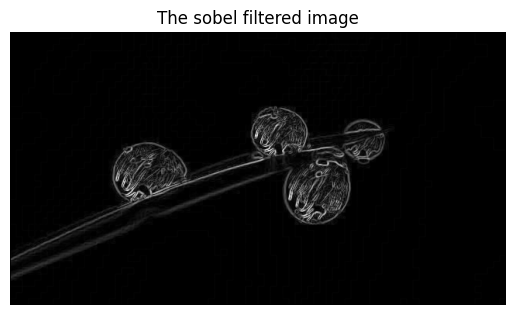

In [7]:
sobel_v_image = sobel_v_filter(image)
sobel_h_image = sobel_h_filter(image)
sobel_image=np.sqrt(sobel_v_image**2 + sobel_h_image**2)

plt.imshow(sobel_image, cmap="gray")
plt.axis("off")
plt.title("The sobel filtered image")
plt.show()

#### Canny edge detection

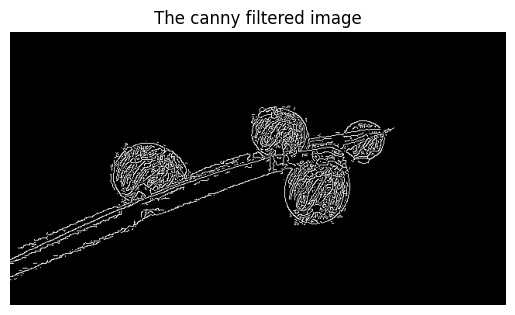

In [8]:
canny_image=cv2.Canny(image,50,100)

plt.imshow(canny_image, cmap="gray")
plt.axis("off")
plt.title("The canny filtered image")
plt.show()

# Task B2:
Add Gaussian noise to the downloaded grayscale image, then:
- Apply the three edge detection methods: Laplacian, Sobel, Canny.
- Smooth the noisy image using Gaussian blur.
- Apply Sobel, Laplacian and Canny again to the smoothing noisy image.
- Compare the edge detection results before and after smoothing.

### Adding noise

In [13]:
noisy_image=image.copy()

def add_gaussian_noise(image,mean,std):
    noise = np.random.normal(mean,std,size=(image.shape[0],image.shape[1]))
    noisy = image[:,:] + noise
    image[:,:] = noisy

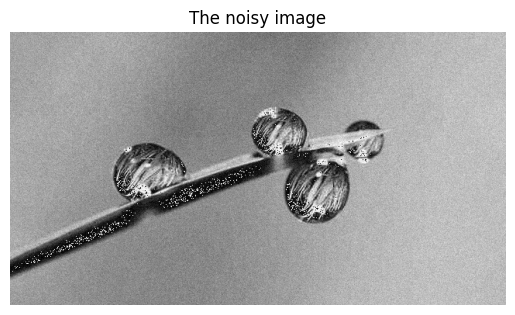

In [14]:
add_gaussian_noise(noisy_image,0,10)

plt.imshow(noisy_image, cmap="gray")
plt.axis("off")
plt.title("The noisy image")
plt.show()

### Applying edge detections

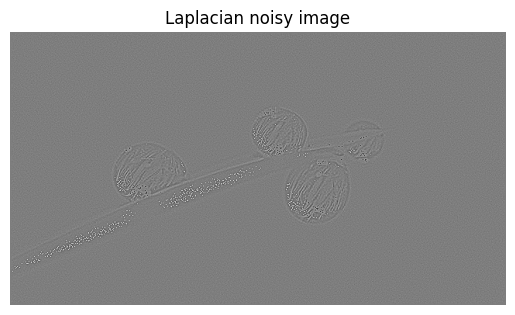

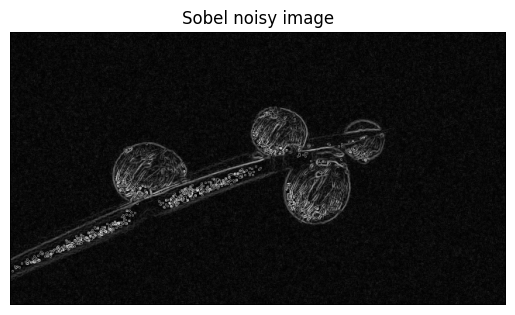

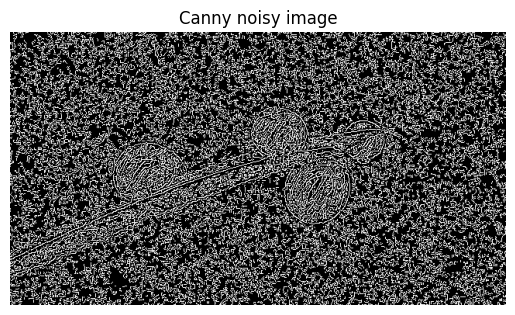

In [18]:
laplacian_noisy_image = log_filter(noisy_image)
sobel_h_noisy_image = sobel_h_filter(noisy_image)
sobel_v_noisy_image = sobel_v_filter(noisy_image)
sobel_noisy_image = np.sqrt(sobel_v_noisy_image**2 + sobel_h_noisy_image**2)
canny_noisy_image = cv2.Canny(noisy_image,50,100)

plt.imshow(laplacian_noisy_image, cmap="gray")
plt.axis("off")
plt.title("Laplacian noisy image")
plt.show()

plt.imshow(sobel_noisy_image, cmap="gray")
plt.axis("off")
plt.title("Sobel noisy image")
plt.show()

plt.imshow(canny_noisy_image, cmap="gray")
plt.axis("off")
plt.title("Canny noisy image")
plt.show()

### Applying Gaussian blur

In [20]:
def gaussian_kernel(size):
    row = np.array([math.comb(size - 1, k) for k in range(size)])
    kernel = np.outer(row, row)
    return kernel / kernel.sum()

def gaussian_filter(image,size):
    for i in range(size//2, image.shape[0] - size//2):
        for j in range(size//2, image.shape[1] - size//2):
            window=image[i-size//2:i+((size//2)+1), j-size//2:j+((size//2)+1)]
            gaussian=(window*gaussian_kernel(size)).sum()
            image[i, j]=gaussian

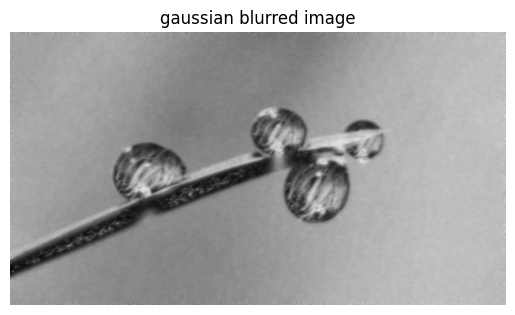

In [28]:
gaussian_blurred_image = noisy_image.copy()

gaussian_filter(gaussian_blurred_image,9)

plt.imshow(gaussian_blurred_image, cmap="gray")
plt.axis("off")
plt.title("gaussian blurred image")
plt.show()

### Applying edge detections again

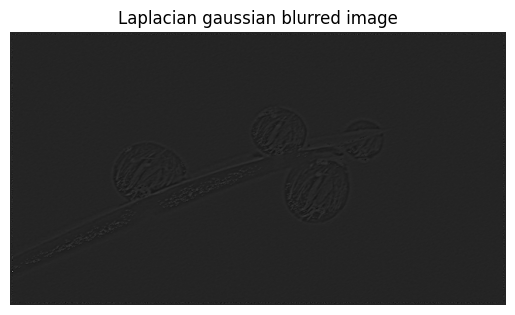

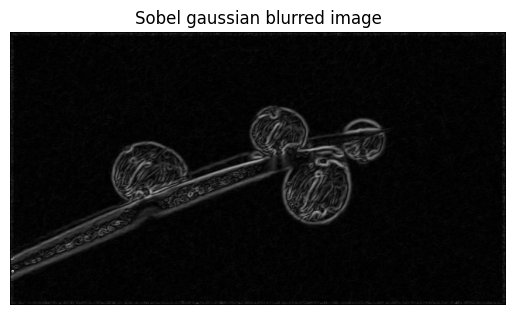

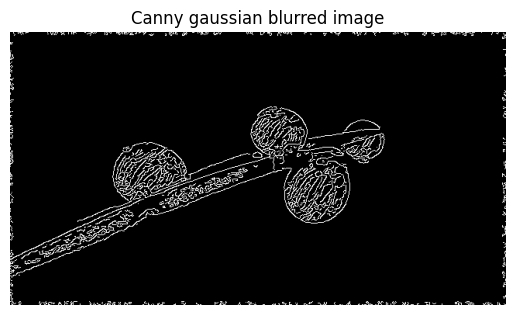

In [29]:
laplacian_gaussian_blurred_image = log_filter(gaussian_blurred_image)
sobel_h_gaussian_blurred_image = sobel_h_filter(gaussian_blurred_image)
sobel_v_gaussian_blurred_image = sobel_v_filter(gaussian_blurred_image)
sobel_gaussian_blurred_image = np.sqrt(sobel_v_gaussian_blurred_image**2 + sobel_h_gaussian_blurred_image**2)
canny_gaussian_blurred_image = cv2.Canny(gaussian_blurred_image,50,100)

plt.imshow(laplacian_gaussian_blurred_image, cmap="gray")
plt.axis("off")
plt.title("Laplacian gaussian blurred image")
plt.show()

plt.imshow(sobel_gaussian_blurred_image, cmap="gray")
plt.axis("off")
plt.title("Sobel gaussian blurred image")
plt.show()

plt.imshow(canny_gaussian_blurred_image, cmap="gray")
plt.axis("off")
plt.title("Canny gaussian blurred image")
plt.show()

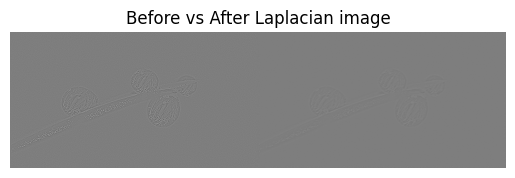

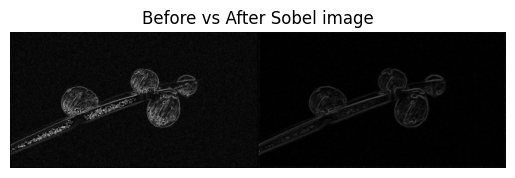

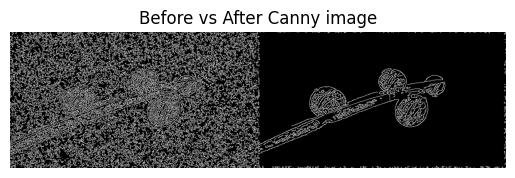

In [31]:
comp_log = np.hstack((laplacian_noisy_image,laplacian_gaussian_blurred_image))
comp_sobel = np.hstack((sobel_noisy_image,sobel_gaussian_blurred_image))
comp_canny = np.hstack((canny_noisy_image,canny_gaussian_blurred_image))

plt.imshow(comp_log, cmap="gray")
plt.axis("off")
plt.title("Before vs After Laplacian image")
plt.show()

plt.imshow(comp_sobel, cmap="gray")
plt.axis("off")
plt.title("Before vs After Sobel image")
plt.show()

plt.imshow(comp_canny, cmap="gray")
plt.axis("off")
plt.title("Before vs After Canny image")
plt.show()